In [1]:
!pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128
!pip install yfinance torch scikit-learn matplotlib pandas numpy
!pip install pandas_market_calendars

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install torch and torchvision==0.27.0.dev20260407+cu128 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested torch
    torchvision 0.27.0.dev20260407+cu128 depends on torch==2.12.0.dev20260407

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


# Importando Bibliotecas

In [2]:
import math
import torch
import numpy as np
import pandas as pd
import yfinance as yf
import torch.nn as nn
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

## Verificando disponibilidade de Gpu

In [3]:
print("GPU disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Modelo da GPU:", torch.cuda.get_device_name(0))

GPU disponível: True
Modelo da GPU: NVIDIA GeForce RTX 5080


# Definindo funções para treinamento da I.A

### Função para buscar dos dados da Ação na bolsa e retornar o volume e o preço de fechamento.

In [4]:
def get_data(start_date:str, end_date:str, ticker:str="PETR4.SA"):
    df = yf.download(ticker, start=start_date, end=end_date)
    return df[['Close', 'Volume']]

### Função para Avaliação do modelo treinado.

In [5]:
def model_evaluation(message:str,scaler,model_predictions:torch.Tensor,y)->None:
    predictions = scaler.inverse_transform(model_predictions)
    real_values = scaler.inverse_transform(y)
    
    mae = mean_absolute_error(real_values, predictions)
    mape = mean_absolute_percentage_error(real_values, predictions) * 100
    rmse = np.sqrt(np.mean((real_values - predictions) ** 2))
    
    print(message)
    print("-" * 50)
    print(f"MAE  (Erro Médio Absoluto)    : R$ {mae:.2f}")
    print(f"MAPE (Erro Percentual Médio)  : {mape:.2f}%")
    print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:.2f}")
    print("-" * 50)

### Função para criar as janelas de dados para treinamento da I.A

In [6]:
def generate_sequences(data, time_window=60):
    X = []
    y = []
    for i in range(len(data) - time_window):
        X.append(data[i : i + time_window])
        y.append(data[i + time_window])
    return np.array(X), np.array(y)

### Função para separar os dados nos tensores X e Y para treinamento do modelo.

In [7]:
def split_data_in_tensors(X,y,seed=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=False)

    # 2. Converter os arrays NumPy para Tensores do PyTorch (tipo float32)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    print(f"Treino - X: {X_train_tensor.shape}, y: {y_train_tensor.shape}")
    print(f"Teste  - X: {X_test_tensor.shape}, y: {y_test_tensor.shape}")
    return X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test


### Função para treinamento do modelo por épocas.

In [8]:
def train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,epochs):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions= model(X_train_tensor)
        loss = criterion(predictions, y_train_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] -> Erro (Loss): {loss.item():.6f}")
    

# Definindo estrura da rede neural

Foram criadas duas camadas escondidas de LSTM(Long short-term memory) com 50 "neurônios" cada, com um input de 1 variável para a predição do valor, na camada seguinte a essas duas é um "neurônio" linear(fully-conected) que transforma a sáida dos 50 "neurônios" em 1 valor, o valor de fechamento.

Já no forward, explicando de maneira sucinta, é onde são feita as ligações das camadas definidas anteriormente e definido o caminho que X(janela de dias recebidos) percorre até a previsão do dia seguinte.

In [9]:
class SharesPredictionModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SharesPredictionModel, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        
        out = self.fc(out[:, -1, :])
        return out

# Treinamento

In [10]:
data=get_data("2021-01-01","2026-03-27")
prices = data['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
normalized_prices = scaler.fit_transform(prices)

WINDOW = 60
X, y = generate_sequences(normalized_prices, WINDOW)

print(f"Formato de X (Amostras, Dias, Features): {X.shape}")
print(f"Formato de y (Amostras, Alvo): {y.shape}")

[*********************100%***********************]  1 of 1 completed

Formato de X (Amostras, Dias, Features): (1244, 60, 1)
Formato de y (Amostras, Alvo): (1244, 1)


 Os dados de treinamento(janelas temporais) são separados nos tensores, além disso são definidos o modelo, no formato que definimos antes, a função de perda do modelo como MSEloss(Perda de entropia cruzada binária) e otimizador de modelo como Adam(Adaptive Moment Estimation) e são passados para a função de treinamento do modelo, junto com o numero de epocas de treinamento.

In [11]:

X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test=split_data_in_tensors(X,y)
model = SharesPredictionModel()
EPOCHS = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)
print("Iniciando o treinamento...")
train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,EPOCHS)
print("Treinamento concluído!")


Treino - X: torch.Size([995, 60, 1]), y: torch.Size([995, 1])
Teste  - X: torch.Size([249, 60, 1]), y: torch.Size([249, 1])
Iniciando o treinamento...
Época [10/100] -> Erro (Loss): 0.039805
Época [20/100] -> Erro (Loss): 0.009726
Época [30/100] -> Erro (Loss): 0.002364
Época [40/100] -> Erro (Loss): 0.001000
Época [50/100] -> Erro (Loss): 0.000706
Época [60/100] -> Erro (Loss): 0.000497
Época [70/100] -> Erro (Loss): 0.000342
Época [80/100] -> Erro (Loss): 0.000291
Época [90/100] -> Erro (Loss): 0.000281
Época [100/100] -> Erro (Loss): 0.000276
Treinamento concluído!


# Avaliação do modelo

O modelo é posto em modo de avaliação , e avaliamos ele usando o MAE,MAPE e RMSE.

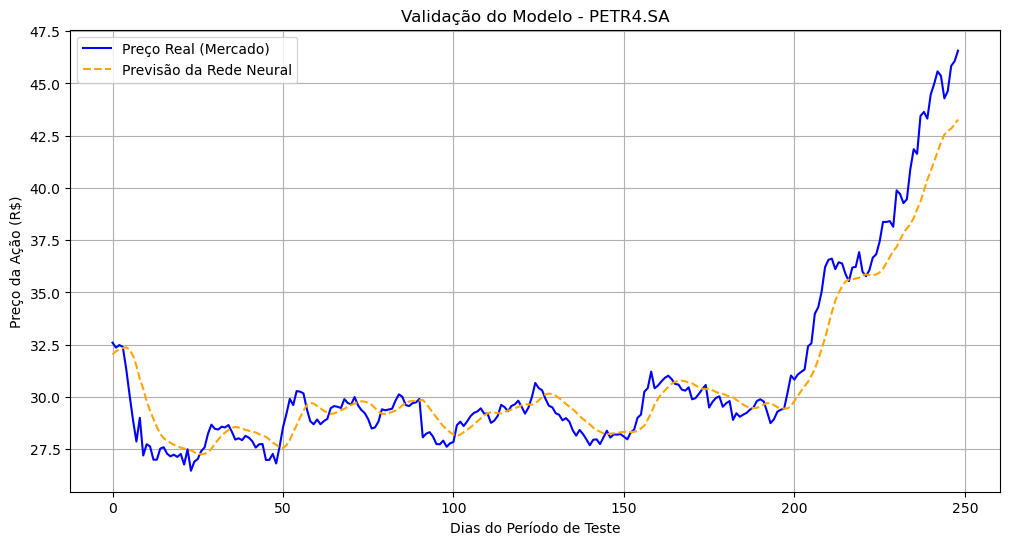

[*********************100%***********************]  1 of 1 completed


--------------------------------------------------
 PREVISÃO PARA O PRÓXIMO DIA ÚTIL:
Preço previsto pela LSTM par o dia(28/05/2026) para PETR4.SA: R$ 42.16


[*********************100%***********************]  1 of 1 completed

Preço real dia seguinte (28/05/2026): R$ 41.81
--------------------------------------------------
 RELATÓRIO DE AVALIAÇÃO DA REDE NEURAL
--------------------------------------------------
MAE  (Erro Médio Absoluto)    : R$ 0.88
MAPE (Erro Percentual Médio)  : 2.70%
RMSE (Raiz do Erro Quadrático): R$ 1.25
--------------------------------------------------


In [12]:
ticker="PETR4.SA"
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    
unnormalized_predictions = scaler.inverse_transform(predictions)
real_values = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 6))
plt.plot(real_values, label="Preço Real (Mercado)", color="blue")
plt.plot(unnormalized_predictions, label="Previsão da Rede Neural", color="orange", linestyle="--")
plt.title(f"Validação do Modelo - {ticker}")
plt.xlabel("Dias do Período de Teste")
plt.ylabel("Preço da Ação (R$)")
plt.legend()
plt.grid(True)
plt.show()
large_history=get_data("2026-01-01", "2026-05-28")
last_60_days=scaler.transform(large_history['Close'].tail(60).values.reshape(-1, 1))
tomorrow_entrance = torch.tensor(last_60_days, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    prediction = model(tomorrow_entrance).numpy()

unnormalized_prediction = scaler.inverse_transform(prediction)

print("-" * 50)
print(f" PREVISÃO PARA O PRÓXIMO DIA ÚTIL:")
print(f"Preço previsto pela LSTM par o dia(28/05/2026) para {ticker}: R$ {unnormalized_prediction[0][0]:.2f}")
print(f"Preço real dia seguinte (28/05/2026): R$ {float(get_data('2026-05-28','2026-05-29')['Close'].values.item()):.2f}")
print("-" * 50)
message=" RELATÓRIO DE AVALIAÇÃO DA REDE NEURAL"
model_evaluation(message,scaler ,predictions,y_test_tensor)

# Salvando modelo(pesos e scaler)

Salvo os pesos no arquivo .pth que seriam o cérebro da I.A, e o scaler que seria o tradutor de dados da I.A .

In [13]:
import torch
import joblib

model_path = "ai_model_petr4.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Modelo salvo com sucesso em: {model_path}")

scaler_path = "scaler_petr4.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler salvo com sucesso em: {scaler_path}")

✅ Modelo salvo com sucesso em: ai_model_petr4.pth
✅ Scaler salvo com sucesso em: scaler_petr4.pkl


# Exemplo: Carregando modelo salvo

Abaixo tem um exemplo de como carregar o modelo treinado,apartir dos arquivos salvos, e como realizar uma inferência utilizando o modelo.

In [14]:
import torch
import joblib
import torch.nn as nn
import yfinance as yf

class SharesPredictionModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SharesPredictionModel, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        
        out = self.fc(out[:, -1, :])
        return out


loaded_X_scaler = joblib.load("scaler_petr4.pkl")

loaded_model = SharesPredictionModel(input_size=1, hidden_size=50, num_layers=2)

loaded_model.load_state_dict(torch.load("ai_model_petr4.pth"))

loaded_model.eval()

print("Modelo preditivo carregado!")


large_history=get_data("2026-01-01", "2026-05-28")
last_60_days=scaler.transform(large_history['Close'].tail(60).values.reshape(-1, 1))
ai_entrance = torch.tensor(last_60_days, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    prediction = loaded_model(ai_entrance).numpy()





unnormalized_prediction = scaler.inverse_transform(prediction)

print("-" * 50)
print(f" PREVISÃO PARA O PRÓXIMO DIA ÚTIL:")
print(f"Preço previsto pela LSTM par o dia(28/05/2026) para {ticker}: R$ {unnormalized_prediction[0][0]:.2f}")
print(f"Preço real dia seguinte (28/05/2026): R$ {float(get_data('2026-05-28','2026-05-29')['Close'].values.item()):.2f}")
print("-" * 50)
message=" RELATÓRIO DE AVALIAÇÃO DA REDE NEURAL"
model_evaluation(message,scaler ,predictions,y_test_tensor)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Modelo preditivo carregado!
--------------------------------------------------
 PREVISÃO PARA O PRÓXIMO DIA ÚTIL:
Preço previsto pela LSTM par o dia(28/05/2026) para PETR4.SA: R$ 42.16
Preço real dia seguinte (28/05/2026): R$ 41.81
--------------------------------------------------
 RELATÓRIO DE AVALIAÇÃO DA REDE NEURAL
--------------------------------------------------
MAE  (Erro Médio Absoluto)    : R$ 0.88
MAPE (Erro Percentual Médio)  : 2.70%
RMSE (Raiz do Erro Quadrático): R$ 1.25
--------------------------------------------------
